<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment9/DNN_Assignment_9_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Library Import

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Transform: No augmentation

In [8]:

transform = transforms.Compose([
    transforms.ToTensor(),  # Only convert to tensor, no augmentation
])

# CIFAR-10 Dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
classes = train_dataset.classes

# Simple CNN Classifier

In [9]:

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

#  Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

#  Training Loop
print("Training CNN without data augmentation...")
for epoch in range(15):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Accuracy={acc:.2f}%")


Training CNN without data augmentation...
Epoch 1: Loss=581.5455, Accuracy=46.40%
Epoch 2: Loss=399.2599, Accuracy=63.89%
Epoch 3: Loss=325.5913, Accuracy=70.89%
Epoch 4: Loss=273.0591, Accuracy=75.64%
Epoch 5: Loss=225.7164, Accuracy=79.84%
Epoch 6: Loss=183.1980, Accuracy=83.69%
Epoch 7: Loss=138.6269, Accuracy=87.72%
Epoch 8: Loss=99.5717, Accuracy=91.22%
Epoch 9: Loss=67.1823, Accuracy=94.21%
Epoch 10: Loss=46.0394, Accuracy=96.02%
Epoch 11: Loss=32.4414, Accuracy=97.18%
Epoch 12: Loss=31.4312, Accuracy=97.24%
Epoch 13: Loss=25.7970, Accuracy=97.70%
Epoch 14: Loss=19.8860, Accuracy=98.28%
Epoch 15: Loss=20.2428, Accuracy=98.21%


# Evaluation on Test Set

In [10]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"\n Test Accuracy (no augmentation): {test_acc:.2f}%")


 Test Accuracy (no augmentation): 72.18%


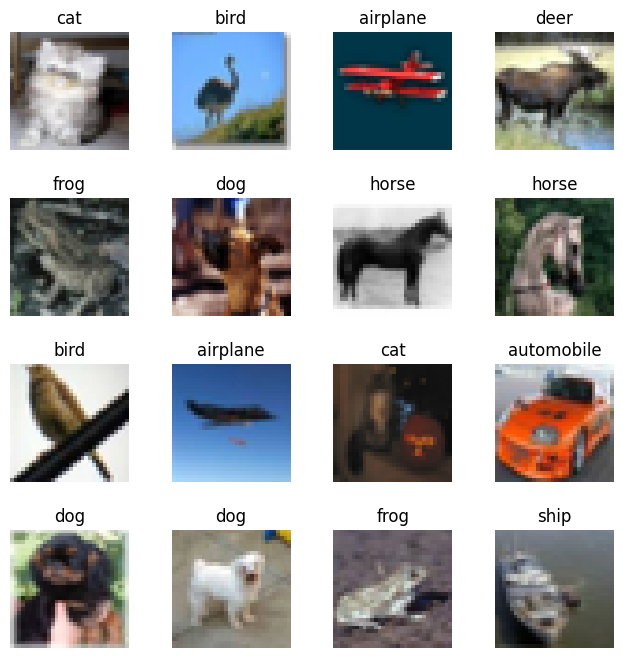

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def imshow_grid(images, labels, class_names):
    images = images[:16]  # take first 16 images
    labels = labels[:16]

    images = images.numpy()
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.subplots_adjust(hspace=0.4)

    for i, ax in enumerate(axes.flat):
        img = np.transpose(images[i], (1, 2, 0))  # CHW → HWC
        ax.imshow(img)
        ax.set_title(class_names[labels[i]])
        ax.axis('off')

    plt.show()
# Grab one batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Call the function
imshow_grid(images, labels, classes)
